In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from opencv_tools import opencv_tools # 匯入封裝的功能

# 第 3 章 認識 OpenCV 中的影像與色彩

# 3-1 認識 OpenCV 的 BGR 顏色通道

### 3-1-1 程式範例：透過 OpenCV 建立全黑的影像

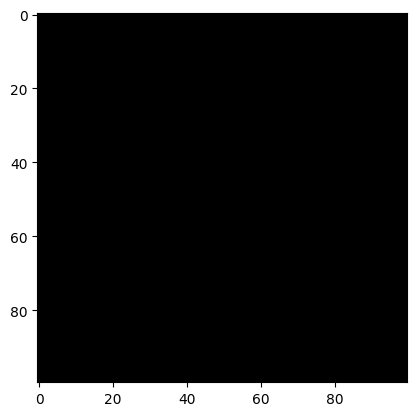

In [2]:
shape = (100, 100, 3) # h, w, c
origin_img = np.zeros(shape, np.uint8)
opencv_tools.show_img_by_matplotlib(origin_img) # 使用 1-E 封裝方法的顯示影像

### 3-1-2 程式範例：透過 OpenCV 建立全白的影像

* 方法一：使用「np.full」建立全白的影像

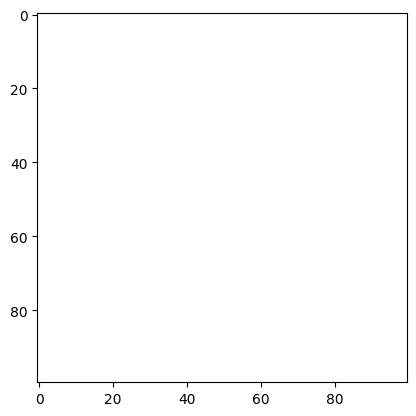

In [3]:
shape = (100, 100, 3)
origin_img = np.full(shape, 255).astype(np.uint8)
opencv_tools.show_img_by_matplotlib(origin_img)

* 方法二：先建立全黑影像，再透過「img.fill(255)」將所有像素值改為白色。

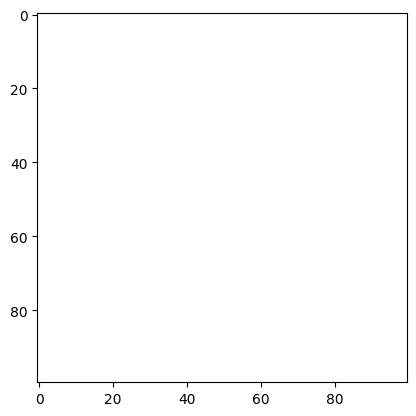

In [4]:
shape = (100, 100, 3)
origin_img = np.zeros(shape, np.uint8)  # 建立全黑影像
origin_img.fill(255)
opencv_tools.show_img_by_matplotlib(origin_img)


In [5]:
### 3-1-3 程式範例：建立其他純色影像

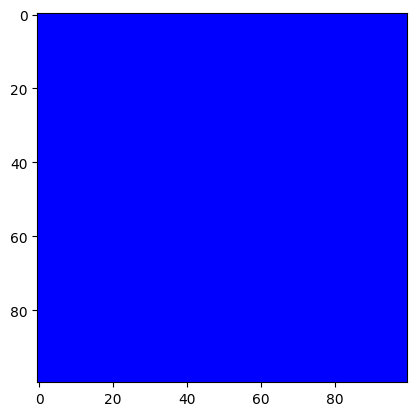

In [6]:
shape = (100, 100, 3)
origin_img = np.zeros(shape, np.uint8)
origin_img[:, :, 0] = 255
opencv_tools.show_img_by_matplotlib(origin_img)

### 3-1-3 程式範例：建立其他純色影像

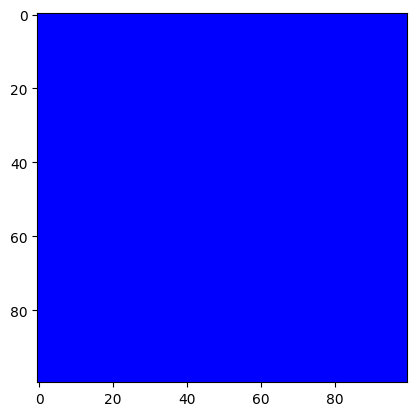

In [7]:
# 藍色影像：將 B通道填滿 (B=255, G=0, R=0)

shape = (100, 100, 3)  
origin_img = np.zeros(shape, np.uint8)
origin_img[:, :, 0] = 255  # 把B通道填滿, 兩個「:」分別替代 y,x 在該通道的所有座標點 
opencv_tools.show_img_by_matplotlib(origin_img) # 透過 matplotlib 顯示影像

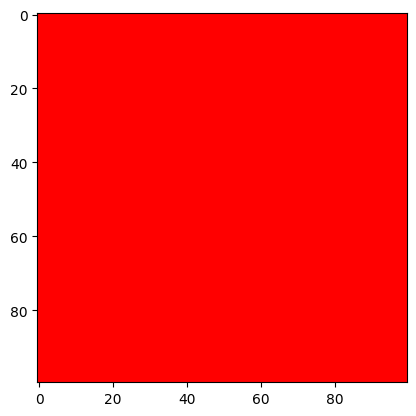

In [8]:
# 紅色影像：將 R通道填滿 (B=0, G=0, R=255)

shape = (100, 100, 3)  
origin_img = np.zeros(shape, np.uint8)
origin_img[:, :, 2] = 255  # 把 R通道填滿, 兩個「:」分別替代 y,x 在該通道的所有座標點 
opencv_tools.show_img_by_matplotlib(origin_img)

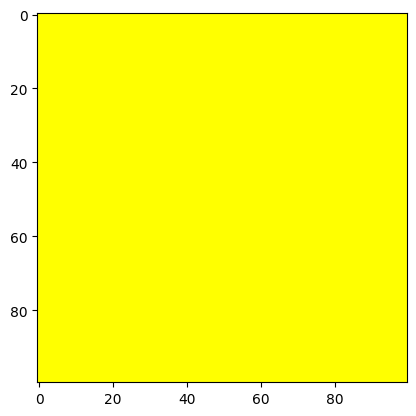

In [9]:
# 黃色影像：綠色加紅色可以得到黃色，因此我們將 G, R通道填滿 (B=0, G=255, R=255)

shape = (100, 100, 3)  
origin_img = np.zeros(shape, np.uint8)
origin_img[:, :, 1] = 255  # 把 G通道填滿
origin_img[:, :, 2] = 255  # 把 R通道填滿 
opencv_tools.show_img_by_matplotlib(origin_img)

# 3-2 拆解與合併 OpenCV 的 BGR 顏色通道

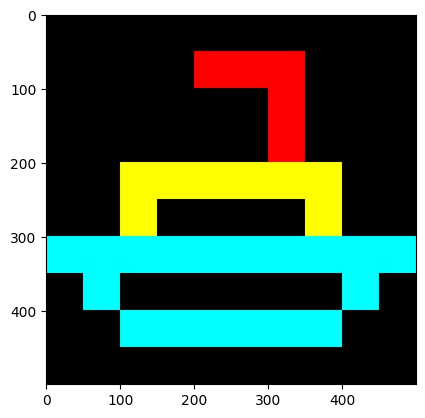

In [10]:
img = cv2.imread("sample/colored_boat.jpg")
opencv_tools.show_img_by_matplotlib(img)

### 3-2-1 分離 BGR 三通道：cv2.split

In [11]:
B, G, R = cv2.split(img)  # cv2.split 將原影像拆解為 B、G、R 三個通道（channel）

* 顯示 R 通道的狀態

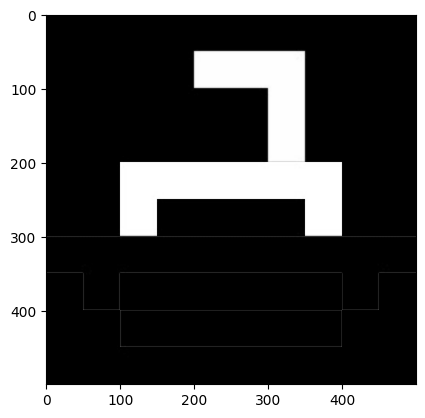

In [12]:
opencv_tools.show_img_by_matplotlib(R)

* 同時顯示 RGB 三個通道的狀態

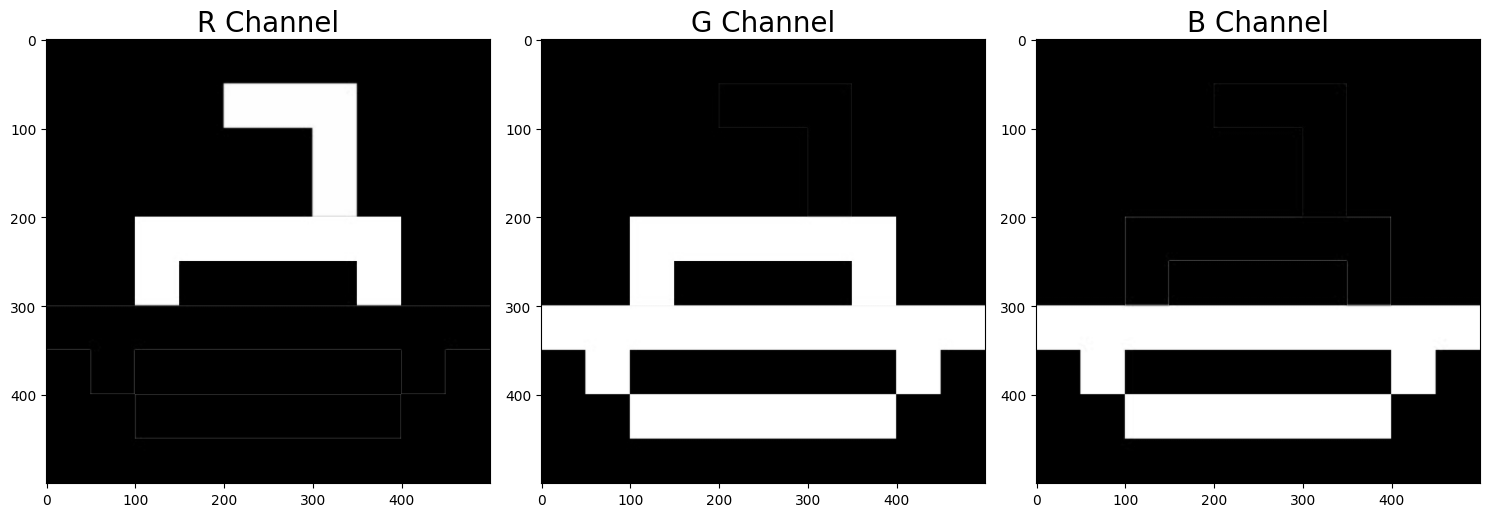

In [13]:
# 使用 1-E 章節中封裝的 show_img_by_matplotlib_1x3，同時顯示 3 組結果
opencv_tools.show_img_by_matplotlib_1x3(
    "R Channel", R, 
    "G Channel", G, 
    "B Channel", B
)

### 3-2-2 合併 BGR 三通道：cv2.merge

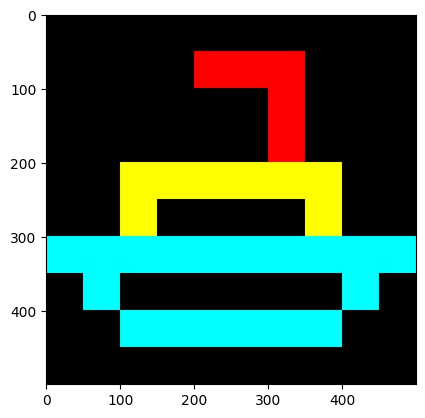

In [14]:
merged_image = cv2.merge([B, G, R])
opencv_tools.show_img_by_matplotlib(merged_image) # 顯示合併結果

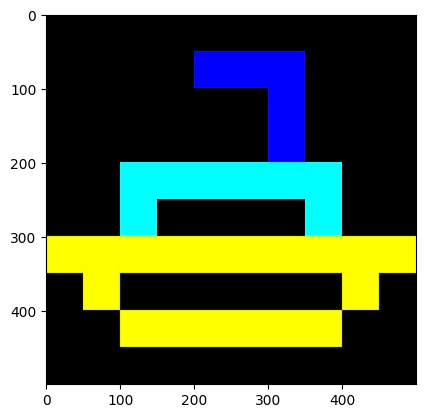

In [15]:
merged_image_wrong = cv2.merge([R, G, B]) # 錯誤順序的合併方式
opencv_tools.show_img_by_matplotlib(merged_image_wrong) # 顯示錯誤合併結果

### 3-2-3 色彩空間轉換：cv2.cvtColor

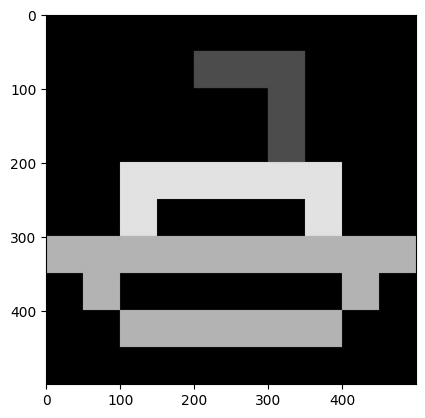

In [16]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
opencv_tools.show_img_by_matplotlib(gray)

### 3-2-4 補充：單一通道的彩色化視覺化

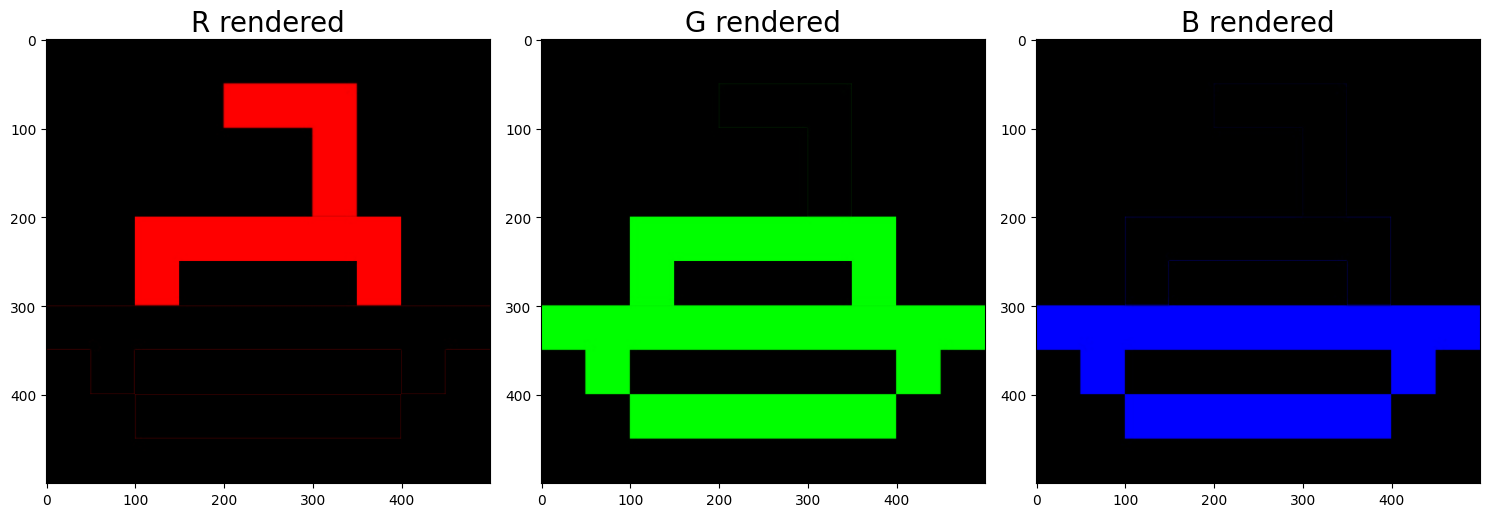

In [17]:
# 建立一個與原圖大小相同，但值全部為 0 的通道
zeros = np.zeros(img.shape[:2], dtype=np.uint8)

# 渲染三個通道的彩色影像
R_rendered = cv2.merge([zeros, zeros, R])  # 僅保留 R 通道，其他通道設為 0
G_rendered = cv2.merge([zeros, G, zeros])  # 僅保留 G 通道，其他通道設為 0
B_rendered = cv2.merge([B, zeros, zeros])  # 僅保留 B 通道，其他通道設為 0

# 使用 1-E 章節中封裝的 show_img_by_matplotlib_1x3，同時顯示 3 組結果
opencv_tools.show_img_by_matplotlib_1x3(
    "R rendered", R_rendered, 
    "G rendered", G_rendered, 
    "B rendered", B_rendered
)

* 使用一張生活中的水果影像做為另外一個例子

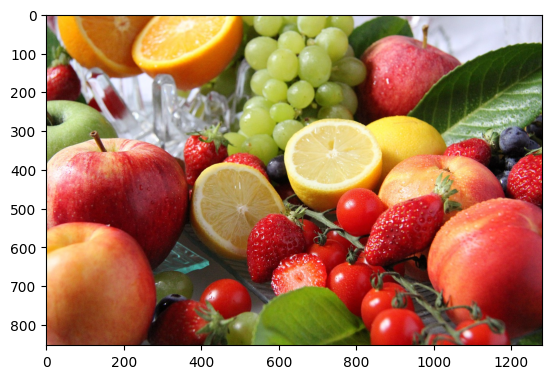

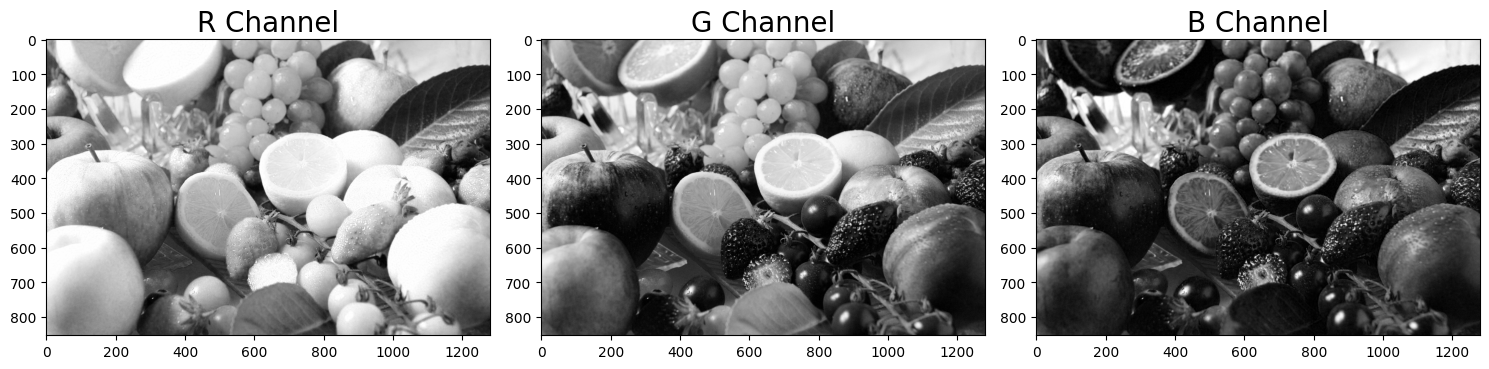

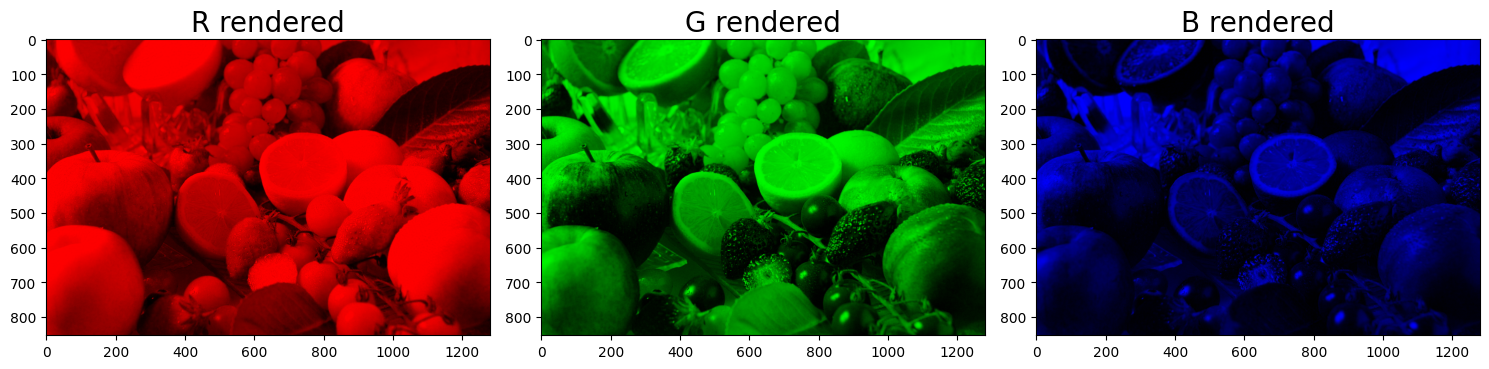

In [18]:
img = cv2.imread("sample/fruits.jpg")
opencv_tools.show_img_by_matplotlib(img)

B, G, R = cv2.split(img)  # cv2.split 將原影像拆解為 B、G、R 三個通道（channel）

# 建立一個與原圖大小相同，但值全部為 0 的通道
zeros = np.zeros(img.shape[:2], dtype=np.uint8)

# 使用 1-E 章節中封裝的 show_img_by_matplotlib_1x3，同時顯示 3 組結果
opencv_tools.show_img_by_matplotlib_1x3(
    "R Channel", R, 
    "G Channel", G, 
    "B Channel", B
)

# 渲染三個通道的彩色影像
R_rendered = cv2.merge([zeros, zeros, R])  # 僅保留 R 通道，其他通道設為 0
G_rendered = cv2.merge([zeros, G, zeros])  # 僅保留 G 通道，其他通道設為 0
B_rendered = cv2.merge([B, zeros, zeros])  # 僅保留 B 通道，其他通道設為 0

# 使用 1-E 章節中封裝的 show_img_by_matplotlib_1x3，同時顯示 3 組結果
opencv_tools.show_img_by_matplotlib_1x3(
    "R rendered", R_rendered, 
    "G rendered", G_rendered, 
    "B rendered", B_rendered
)

### 3-3-2 透過 OpenCV 繪製出直方圖：cv2.calcHist

In [19]:
file_name = "sample/cat.jpg" # 請將要讀取的影像放置在與程式同一個資料夾中
img = cv2.imread(file_name) # 讀取影像

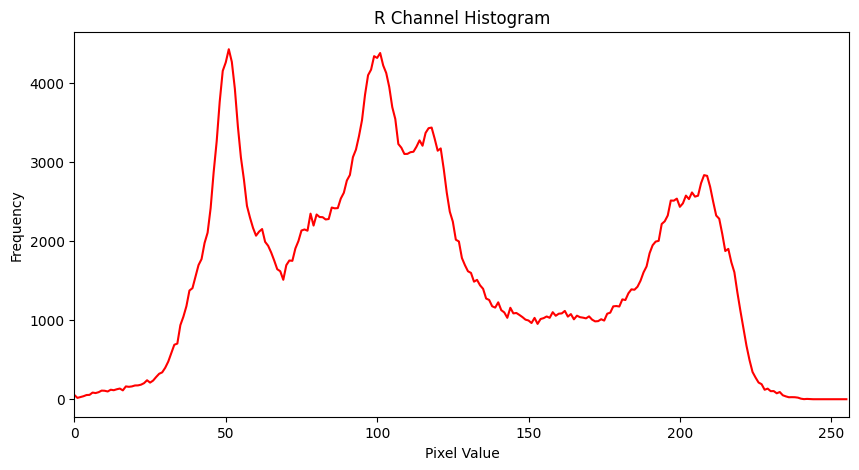

In [20]:
# 定義函式以繪製 R 通道的直方圖
def plot_R_histogram(img):
    # 設定畫布大小
    plt.figure(figsize=(10, 5))

    # 計算 R 通道的直方圖
    histogram = cv2.calcHist([img], [2], None, [256], [0, 256])

    # 繪製直方圖，紅色線條表示 R 通道
    plt.plot(histogram, color='red')

    # 設定圖表標題與軸標籤
    plt.title("R Channel Histogram")
    plt.xlabel("Pixel Value")  # 像素值（0-255）
    plt.ylabel("Frequency")    # 像素值的出現次數
    plt.xlim([0, 256])         # 設定 X 軸範圍

    # 顯示直方圖
    plt.show()

plot_R_histogram(img) # 顯示直方圖

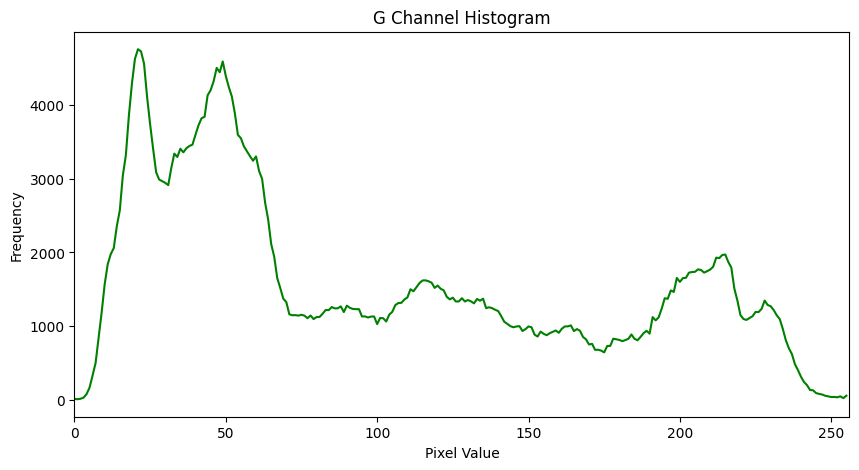

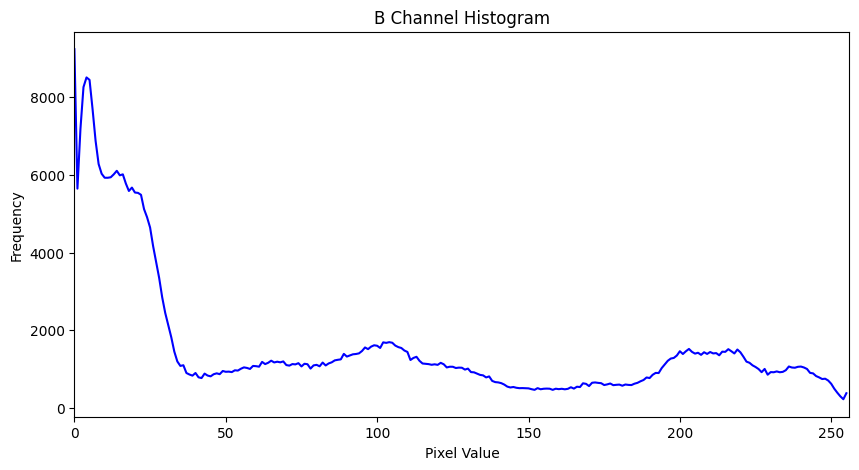

In [21]:
# 定義函式以繪製 G 通道的直方圖
def plot_G_histogram(img):
    plt.figure(figsize=(10, 5))
    histogram = cv2.calcHist([img], [1], None, [256], [0, 256])  # 計算 G 通道的直方圖
    plt.plot(histogram, color='green')  # 使用綠色線條表示 G 通道
    plt.title("G Channel Histogram")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.xlim([0, 256])
    plt.show()

# 定義函式以繪製 B 通道的直方圖
def plot_B_histogram(img):
    plt.figure(figsize=(10, 5))
    histogram = cv2.calcHist([img], [0], None, [256], [0, 256])  # 計算 B 通道的直方圖
    plt.plot(histogram, color='blue')  # 使用藍色線條表示 B 通道
    plt.title("B Channel Histogram")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.xlim([0, 256])
    plt.show()

plot_G_histogram(img) # 顯示直方圖
plot_B_histogram(img) # 顯示直方圖

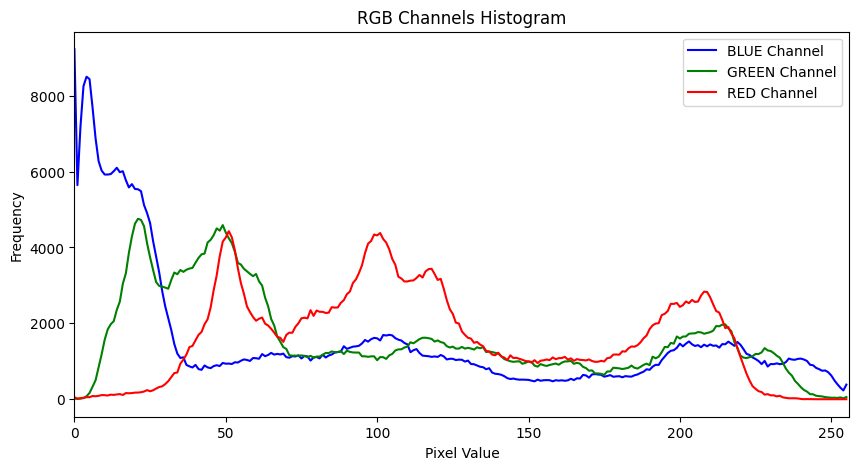

In [22]:
# 定義函式以繪製 RGB 三通道的直方圖
def plot_RGB_histogram(img):
    plt.figure(figsize=(10, 5))

    # 同時繪製並顯示三個通道的直方圖
    colors = ('blue', 'green', 'red')  # 定義顏色順序
    for i, color in enumerate(colors):
        histogram = cv2.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(histogram, color=color, label=f"{color.upper()} Channel")  # 繪製直方圖

    # 設定圖表標題與軸標籤
    plt.title("RGB Channels Histogram")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.xlim([0, 256])
    plt.legend()  # 顯示圖例
    plt.show()

plot_RGB_histogram(img) # 顯示直方圖

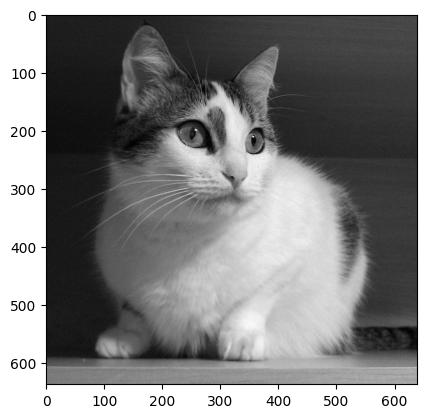

In [23]:
B, G, R = cv2.split(img)  # cv2.split 將原影像拆解為 B、G、R 三個通道（channel）
gray = (1/3 * R + 1/3 * G + 1/3 * B).astype(np.uint8) # 利用平均灰階法計算灰階影像
opencv_tools.show_img_by_matplotlib(gray) # 顯示灰階影像

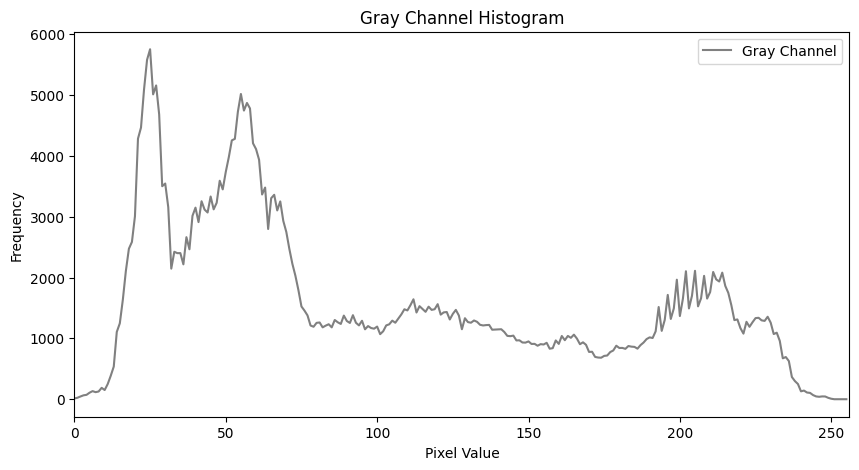

In [24]:
def plot_gray_histogram(img):
    plt.figure(figsize=(10, 5))

    # 計算灰階影像的直方圖
    histogram = cv2.calcHist([img], [0], None, [256], [0, 256]) # 灰階影像只有一個通道，因此是 [0]
    plt.plot(histogram, color='gray', label="Gray Channel")  # 繪製直方圖

    # 設定圖表標題與軸標籤
    plt.title("Gray Channel Histogram")
    plt.xlabel("Pixel Value")  # 像素值（0-255）
    plt.ylabel("Frequency")    # 像素值的出現次數
    plt.xlim([0, 256])         # 設定 X 軸範圍
    plt.legend()  # 顯示圖例
    plt.show()

plot_gray_histogram(gray)  # 顯示灰階影像的直方圖

### 3-3-3 補充：從彩色影像轉換為灰階影像的不同方式

In [25]:
file_name = "sample/cat.jpg" # 請將要讀取的影像放置在與程式同一個資料夾中
img = cv2.imread(file_name) # 讀取影像

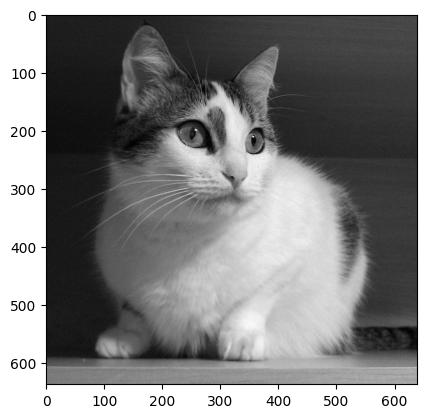

In [26]:
# 方法一：平均灰階法
B, G, R = cv2.split(img)  # 使用 cv2.split 將原影像拆解為 B、G、R 三個通道
gray = (1/3 * R + 1/3 * G + 1/3 * B).astype(np.uint8)  # 利用平均灰階法計算灰階影像
opencv_tools.show_img_by_matplotlib(gray)  # 顯示灰階影像

* 小心數值溢出問題

正常的平均灰階直方圖


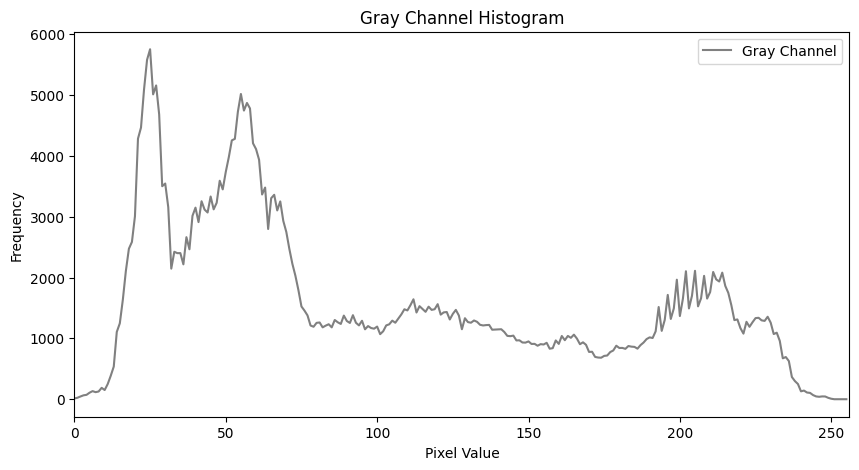

異常的平均灰階直方圖，因為數值溢出


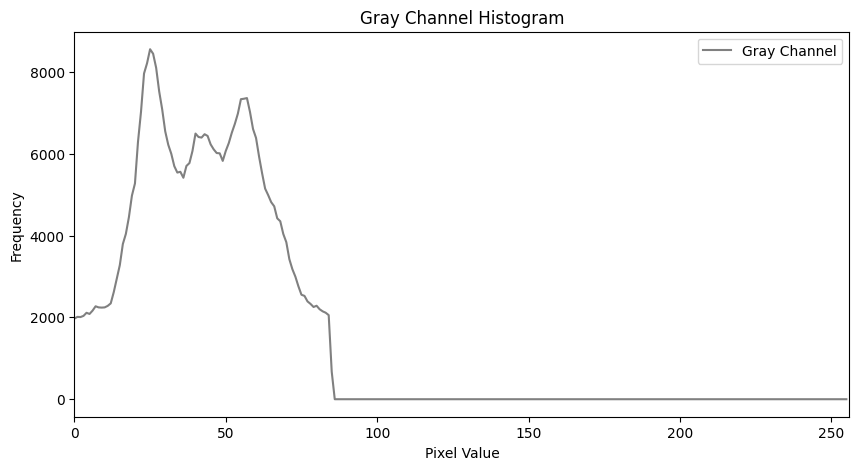

In [27]:
print("正常的平均灰階直方圖")
gray = (1/3 * R + 1/3 * G + 1/3 * B).astype(np.uint8)  # 正確的平均灰階法
plot_gray_histogram(gray)

print("異常的平均灰階直方圖，因為數值溢出")
wrong_gray = ((R + G + B) / 3).astype(np.uint8)  # 錯誤的計算方式，可能導致溢出
plot_gray_histogram(wrong_gray)

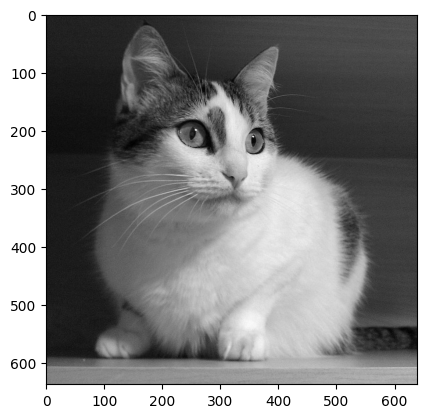

In [28]:
# 方法二：加權灰階法
B, G, R = cv2.split(img)  # 使用 cv2.split 將原影像拆解為 B、G、R 三個通道
weighted_gray = (0.299 * R + 0.587 * G + 0.114 * B).astype(np.uint8)  # 利用加權灰階法計算灰階影像
opencv_tools.show_img_by_matplotlib(weighted_gray)  # 顯示灰階影像

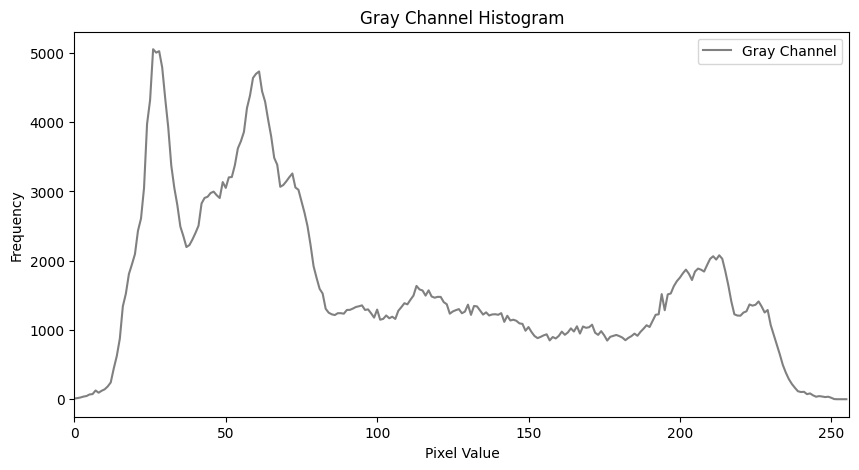

In [29]:
plot_gray_histogram(weighted_gray)

* 使用水果範例來比較兩張灰階影像的不同

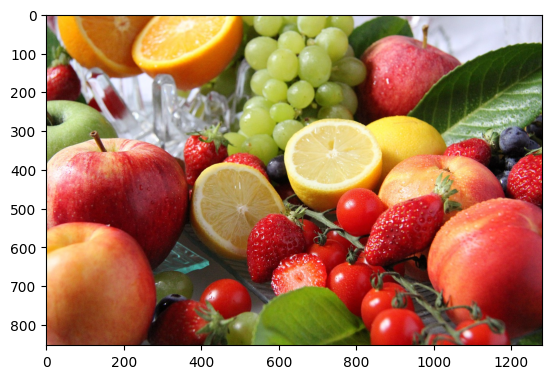

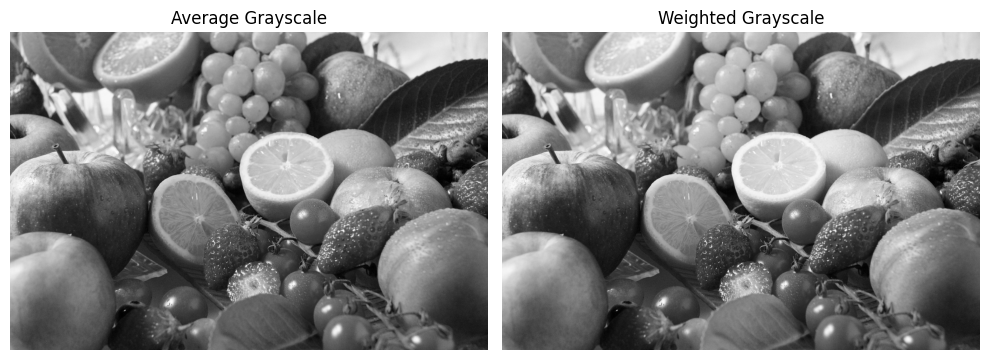

In [30]:
img = cv2.imread("sample/fruits.jpg")
opencv_tools.show_img_by_matplotlib(img)

B, G, R = cv2.split(img)  # cv2.split 將原影像拆解為 B、G、R 三個通道（channel）
gray_averaged = (1/3 * R + 1/3 * G + 1/3 * B).astype(np.uint8) # 利用平均灰階法計算灰階影像
gray_weighted = (0.299 * R + 0.587* G + 0.114* B).astype(np.uint8) # 利用加權灰階法計算灰階影像

# 使用 matplotlib 顯示影像
plt.figure(figsize=(10, 5))

# 顯示平均灰階圖
plt.subplot(1, 2, 1)
plt.imshow(gray_averaged, cmap='gray')
plt.title('Average Grayscale')
plt.axis('off')

# 顯示加權灰階圖
plt.subplot(1, 2, 2)
plt.imshow(gray_weighted, cmap='gray')
plt.title('Weighted Grayscale')
plt.axis('off')

# 顯示所有影像
plt.tight_layout()
plt.show()

## 3-E 小專案：透過 HSV 色彩空間來篩選影像中的紅色

### 3-E-2 將水果影像中紅色的部分篩選出來：程式碼實作

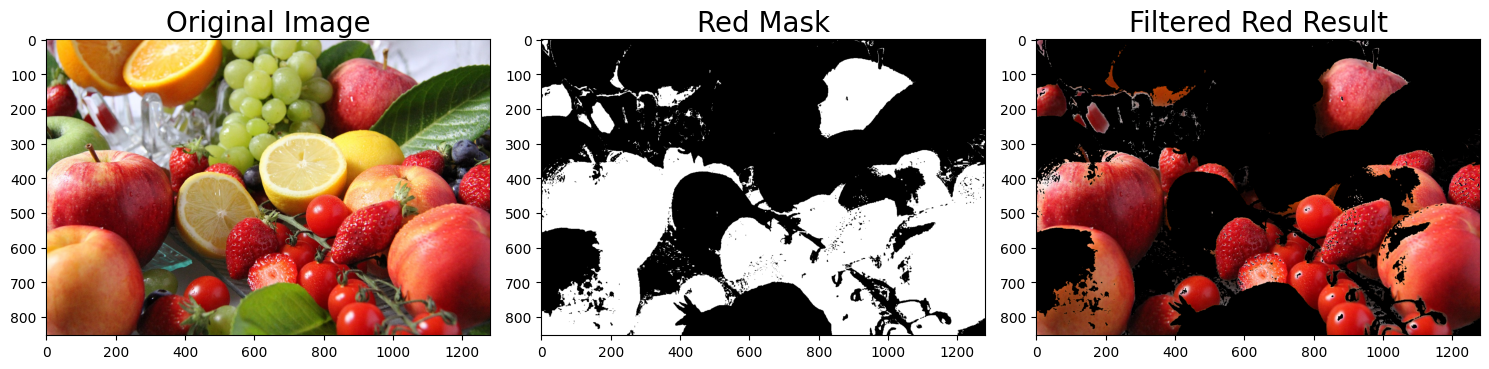

In [31]:
img = cv2.imread('sample/fruits.jpg') # 讀取水果影像

# 將影像從 BGR 色彩空間轉換為 HSV 色彩空間
# 注意：OpenCV 預設讀入影像的色彩空間是 BGR，而非 RGB
hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 定義紅色的 HSV 範圍
# 取出紅色在 HSV 色彩空間的兩段範圍：
# 1. Hue 的低度數範圍（0° ~ 20°，對應 HSV 的 0 ~ 10）
# 2. Hue 的高度數範圍（340° ~ 358°，對應 HSV 的 170 ~ 179）
lower_red1 = np.array([0, 0, 0])       # 紅色低範圍的下界, H = 0, S = 0, V = 0
upper_red1 = np.array([10, 255, 255])  # 紅色低範圍的上界, H = 10, S = 255, V = 255
lower_red2 = np.array([170, 0, 0])     # 紅色高範圍的下界, H = 170, S = 0, V = 0
upper_red2 = np.array([179, 255, 255]) # 紅色高範圍的上界, H = 179, S = 255, V = 255

# 建立遮罩，分別處理兩段紅色範圍
mask1 = cv2.inRange(hsv_image, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv_image, lower_red2, upper_red2)

# 合併兩個遮罩
red_mask = cv2.bitwise_or(mask1, mask2)

# 使用遮罩篩選出原始影像中的紅色區域
red_result = cv2.bitwise_and(img, img, mask=red_mask)

# 使用 1-E 章節中封裝的 show_img_by_matplotlib_1x2，同時顯示原始影像、遮罩和篩選結果
opencv_tools.show_img_by_matplotlib_1x3(
    'Original Image', img,
    'Red Mask', red_mask,
    'Filtered Red Result', red_result,
)

### 3-E-3 將水果影像中紅色的部分篩選出來：其他細節部分

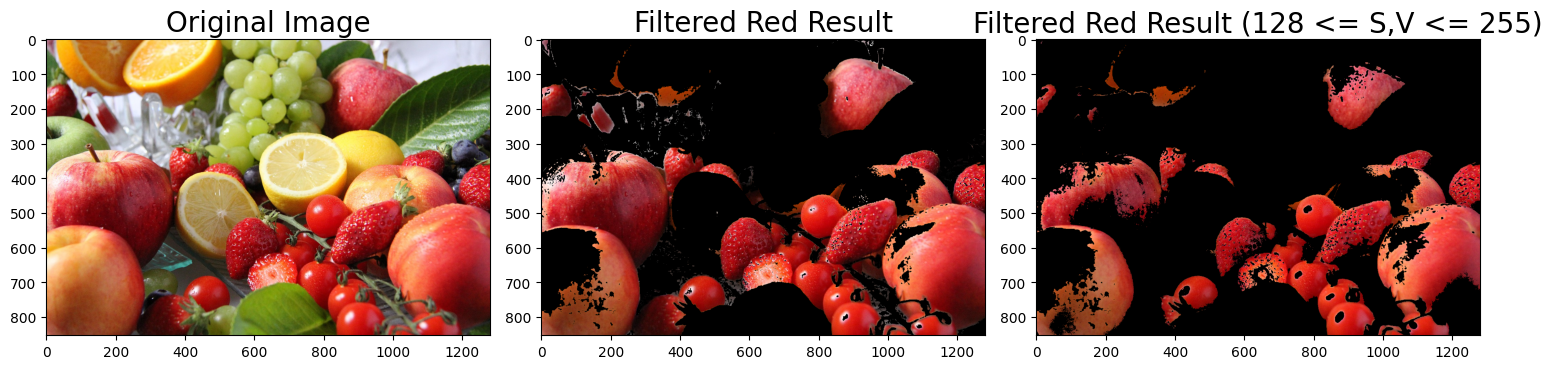

In [32]:
lower_red3 = np.array([0, 128, 128])   # 調整後的紅色低範圍下界, 捨棄 S, V < 128 (保留範圍 128 ~ 255)
upper_red3 = np.array([10, 255, 255])  # 調整後的紅色低範圍上界
lower_red4 = np.array([170, 128, 128]) # 調整後的紅色高範圍下界
upper_red4 = np.array([179, 255, 255]) # 調整後的紅色高範圍上界

# 建立遮罩，分別處理兩段紅色範圍
mask3 = cv2.inRange(hsv_image, lower_red3, upper_red3)
mask4 = cv2.inRange(hsv_image, lower_red4, upper_red4)

# 合併兩個遮罩
new_red_mask = cv2.bitwise_or(mask3, mask4)

# 使用遮罩篩選出原始影像中的紅色區域
new_red_result = cv2.bitwise_and(img, img, mask=new_red_mask)

# 使用 1-E 章節中封裝的 show_img_by_matplotlib_1x3，同時顯示原始影像、遮罩和篩選結果
opencv_tools.show_img_by_matplotlib_1x3(
    'Original Image', img,
    'Filtered Red Result', red_result,
    'Filtered Red Result (128 <= S,V <= 255)', new_red_result,
)